# **Eksperimen Machine Learning - Wine Quality Classification**

**Author:** Ar'raffi Abqori Nur Azizi

**Dataset:** Wine Quality (UCI ML Repository)

**Objective:** Membangun model klasifikasi untuk memprediksi kualitas wine (good/bad) berdasarkan properti fisikokimia.

Notebook ini mengikuti Template Eksperimen MSML sebagai panduan struktur.

# **1. Perkenalan Dataset**

Dataset Wine Quality berasal dari UCI Machine Learning Repository. Dataset ini berisi properti fisikokimia dari varian wine merah dan putih dari Portugal.

**Sumber Dataset:** [UCI ML Repository - Wine Quality](https://archive.ics.uci.edu/ml/datasets/wine+quality)

**Deskripsi:**
- **Red Wine:** 1599 samples
- **White Wine:** 4898 samples
- **Total Features:** 11 fitur fisikokimia + 1 target (quality)
- **Target:** Quality score (0-10), akan dikonversi menjadi binary (good/bad)

**Fitur:**
1. Fixed acidity
2. Volatile acidity
3. Citric acid
4. Residual sugar
5. Chlorides
6. Free sulfur dioxide
7. Total sulfur dioxide
8. Density
9. pH
10. Sulphates
11. Alcohol
12. Quality (target)

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# Data manipulation & analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Utilities
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

All libraries imported successfully!
pandas: 2.2.3
numpy: 2.2.2


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset Wine Quality dari UCI ML Repository.
Dataset terdiri dari dua file: Red Wine dan White Wine, yang akan digabungkan menjadi satu dataset.

In [2]:
# Load Red Wine dataset
url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df_red = pd.read_csv(url_red, sep=';')
df_red['wine_type'] = 'red'

# Load White Wine dataset
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
df_white = pd.read_csv(url_white, sep=';')
df_white['wine_type'] = 'white'

# Combine both datasets
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

print(f'Red wine samples  : {len(df_red)}')
print(f'White wine samples: {len(df_white)}')
print(f'Total samples     : {len(df)}')
print(f'\nDataset Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')

Red wine samples  : 1599
White wine samples: 4898
Total samples     : 6497

Dataset Shape: (6497, 13)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type']


In [3]:
# Preview dataset
print('First 5 rows:')
df.head()

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [4]:
# Dataset info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [5]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
# Save raw data locally
os.makedirs('../winequality_raw', exist_ok=True)
df_red.drop(columns=['wine_type']).to_csv('../winequality_raw/winequality-red.csv', index=False, sep=';')
df_white.drop(columns=['wine_type']).to_csv('../winequality_raw/winequality-white.csv', index=False, sep=';')
print('Raw data saved to ../winequality_raw/')

Raw data saved to ../winequality_raw/


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
# 4.1 Cek Missing Values
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Total missing values: 0


In [8]:
# 4.2 Cek Duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')
print(f'Persentase duplikat: {duplicates/len(df)*100:.2f}%')

Jumlah baris duplikat: 1177
Persentase duplikat: 18.12%


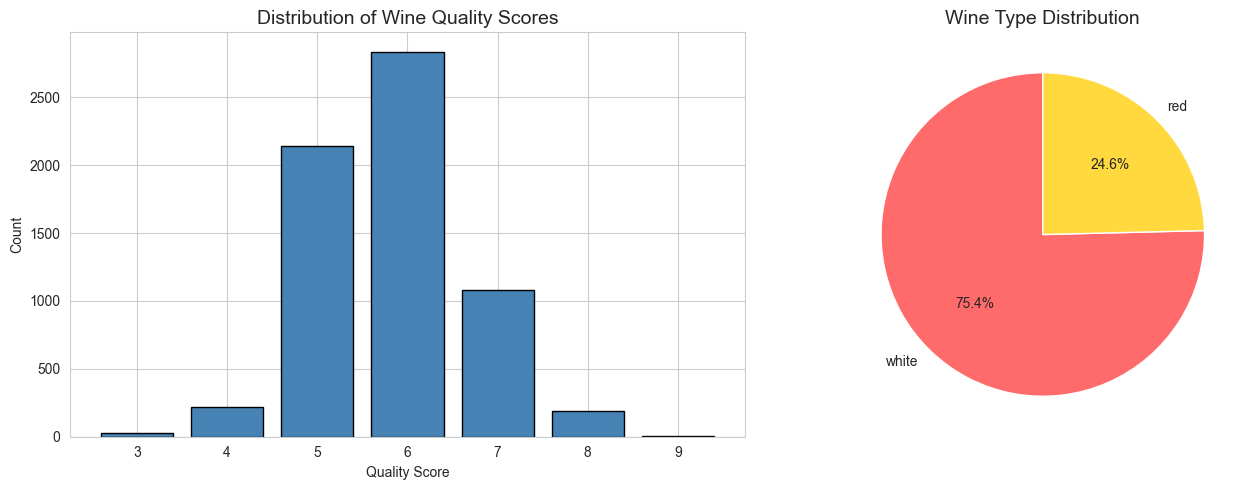

In [9]:
# 4.3 Distribusi Target Variable (Quality)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality distribution
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Wine Quality Scores', fontsize=14)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

# Wine type distribution
wine_type_counts = df['wine_type'].value_counts()
axes[1].pie(wine_type_counts.values, labels=wine_type_counts.index, 
            autopct='%1.1f%%', colors=['#FF6B6B', '#FFD93D'], startangle=90)
axes[1].set_title('Wine Type Distribution', fontsize=14)

plt.tight_layout()
plt.show()

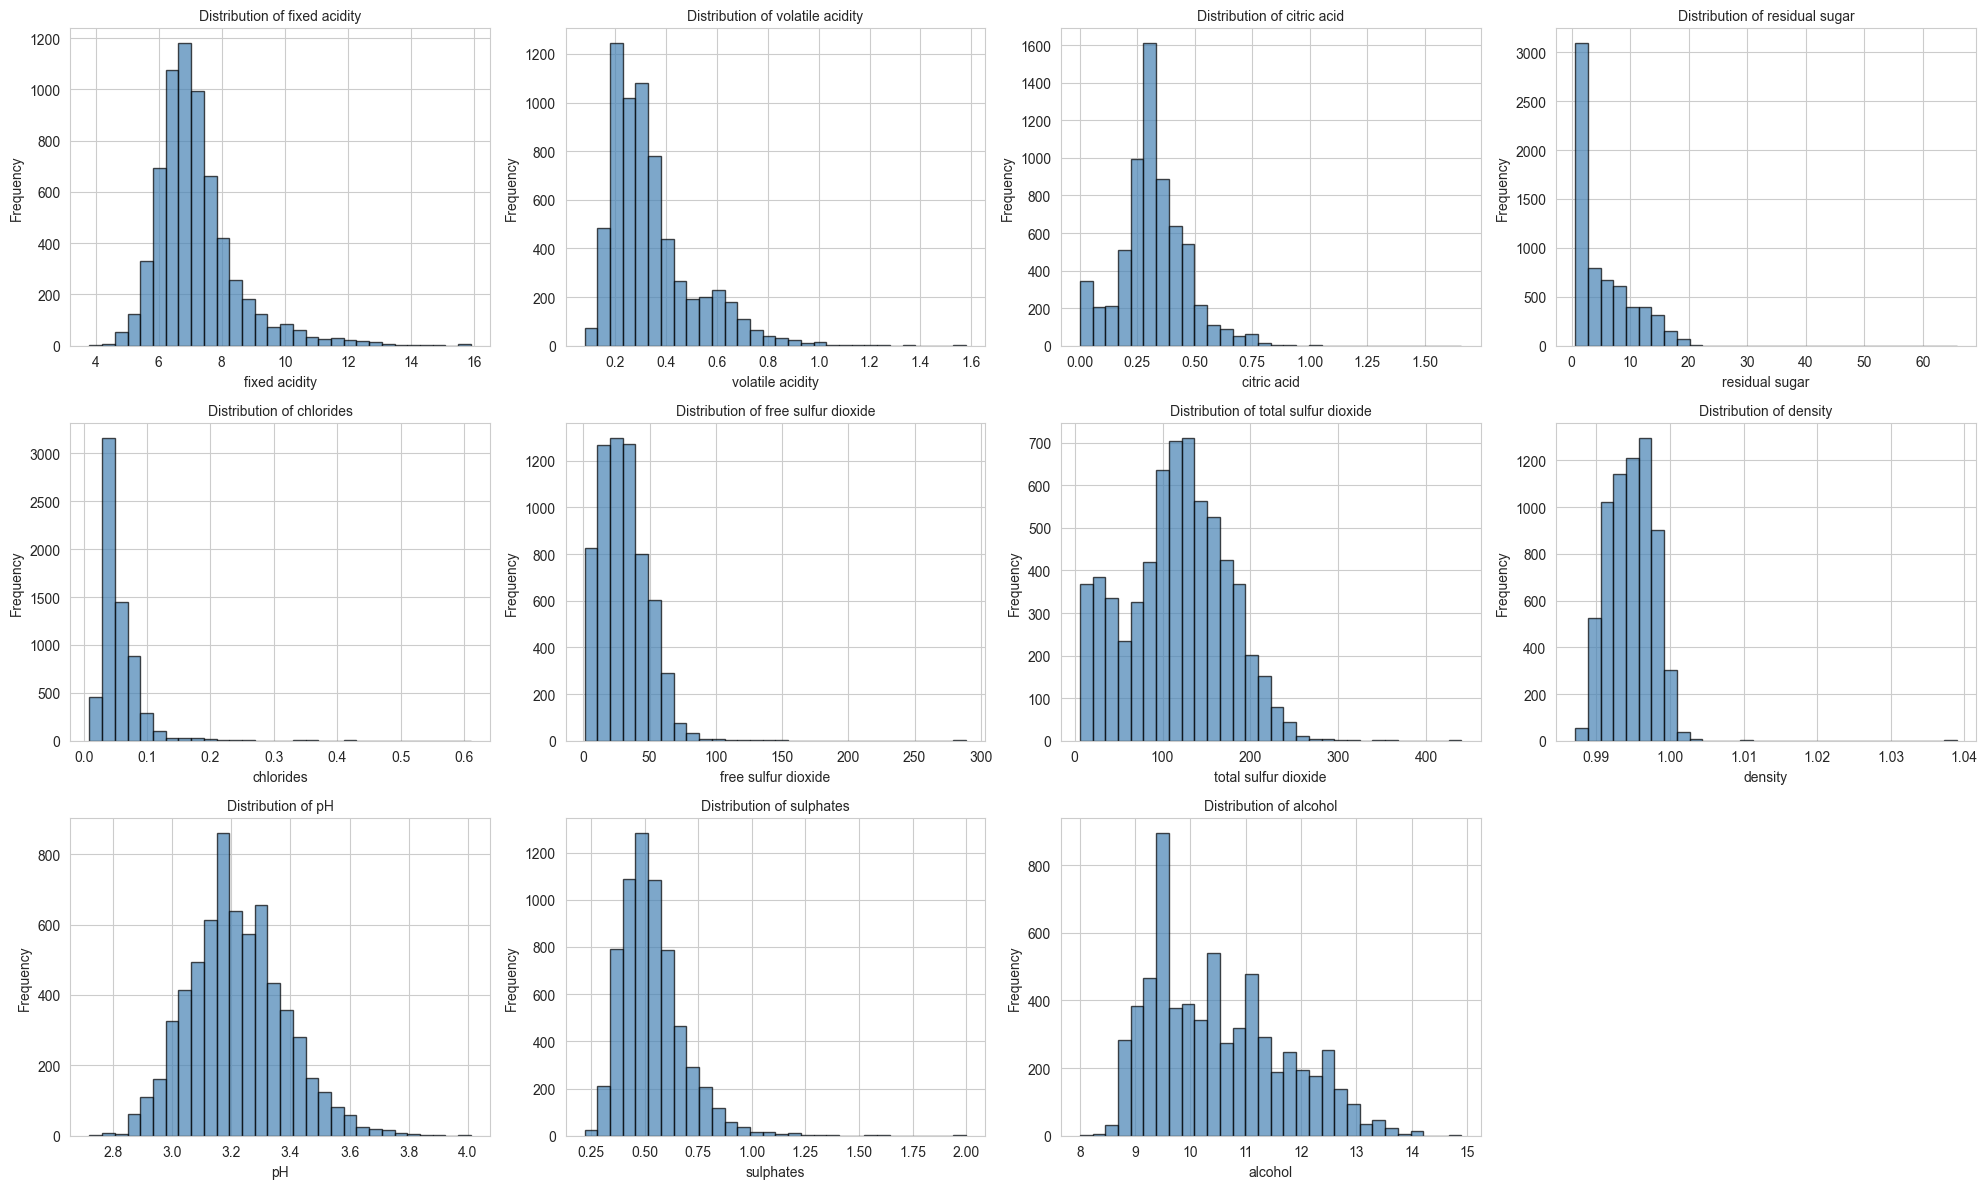

In [10]:
# 4.4 Distribusi Fitur Numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('quality')  # exclude target

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

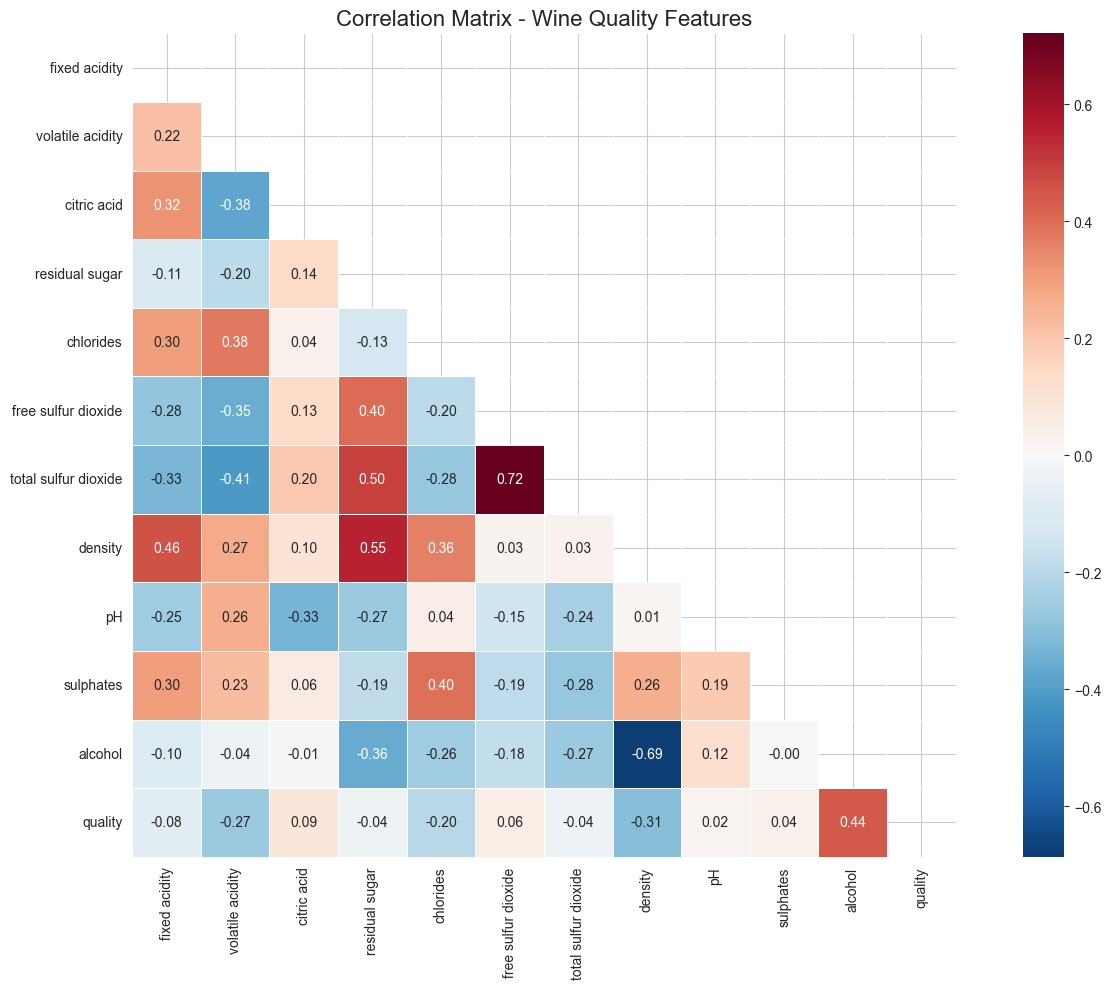

In [11]:
# 4.5 Correlation Matrix
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Wine Quality Features', fontsize=16)
plt.tight_layout()
plt.show()

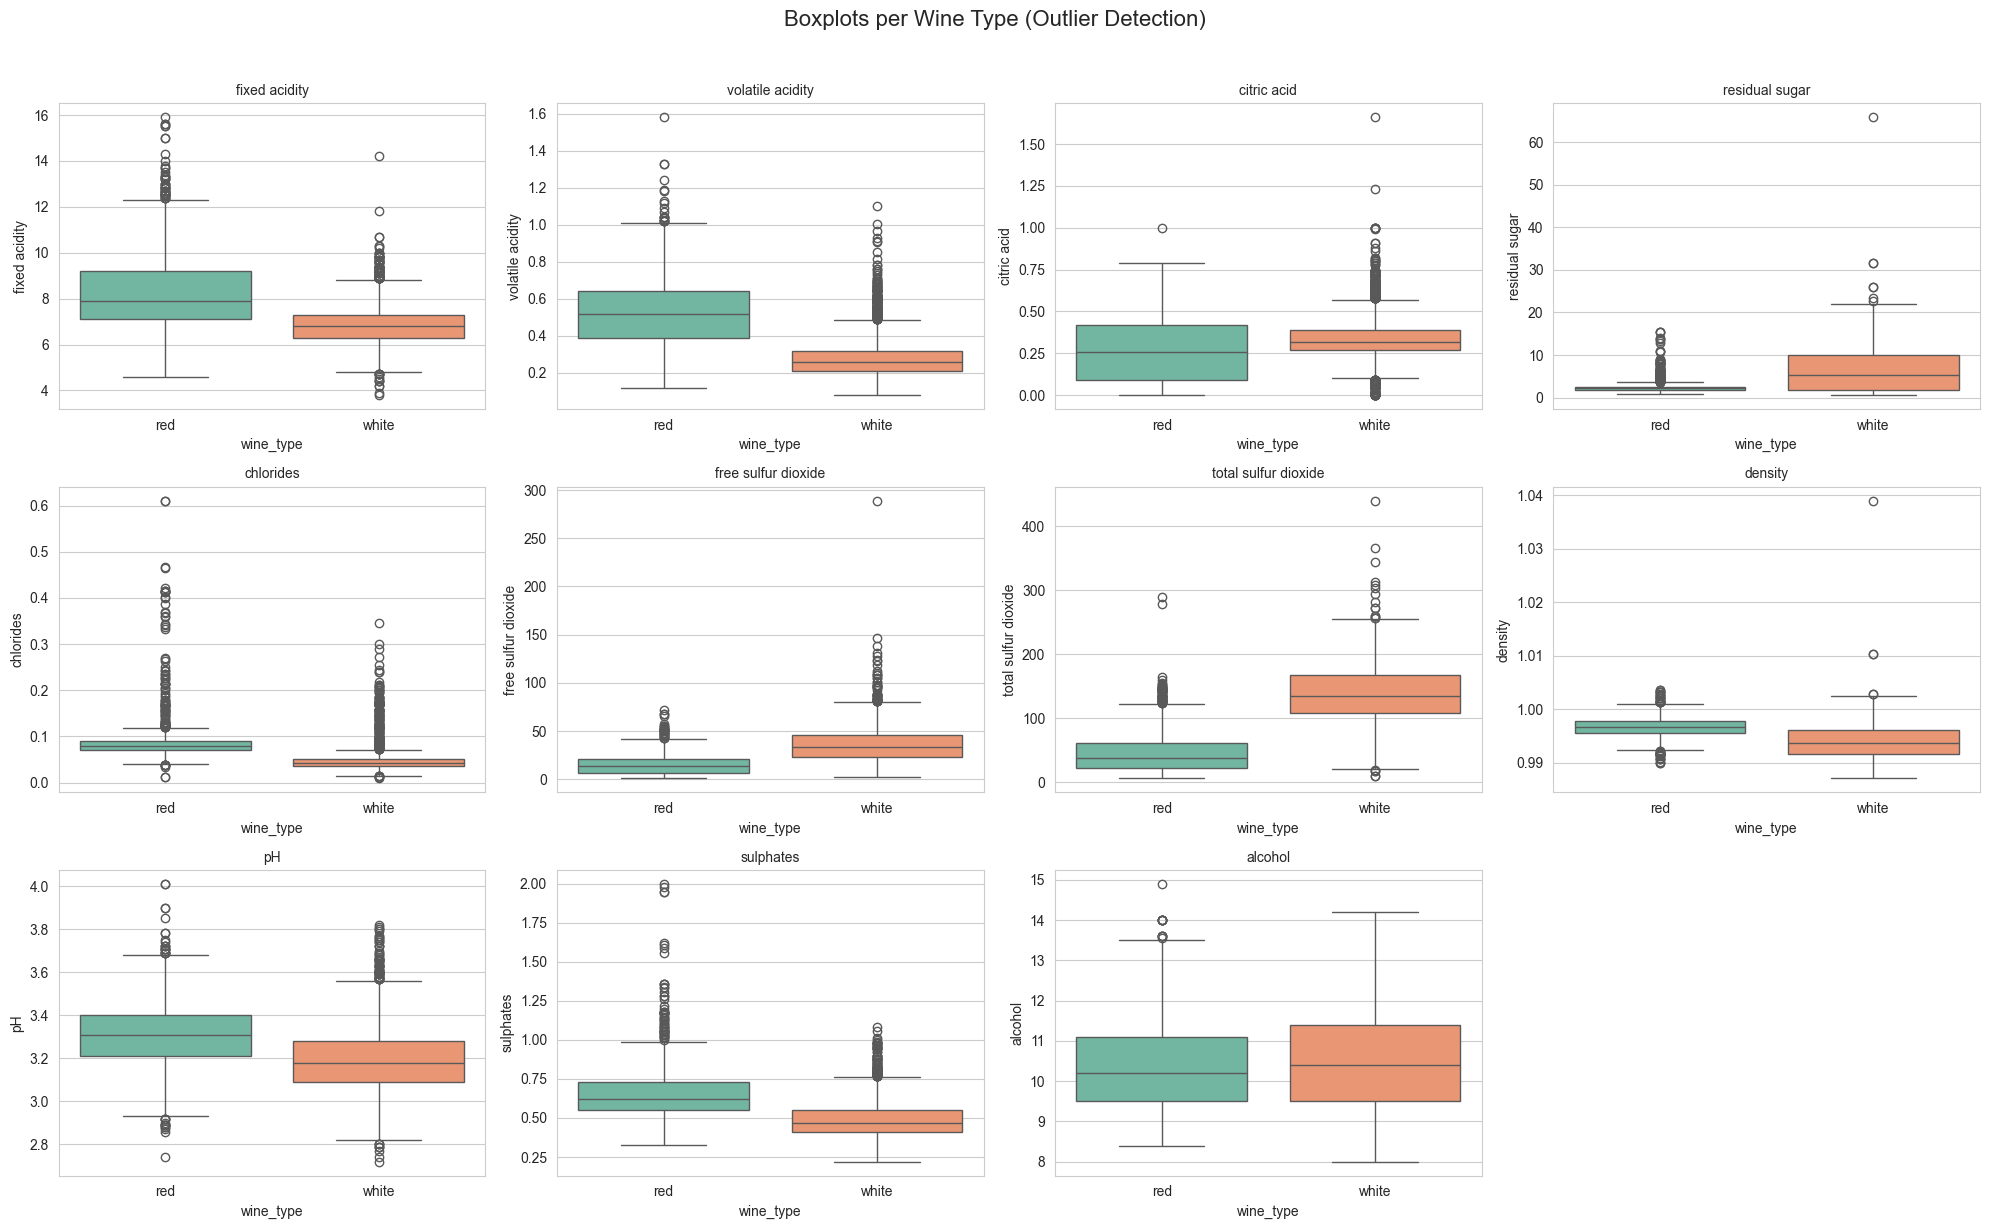

In [12]:
# 4.6 Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='wine_type', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col}', fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots per Wine Type (Outlier Detection)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

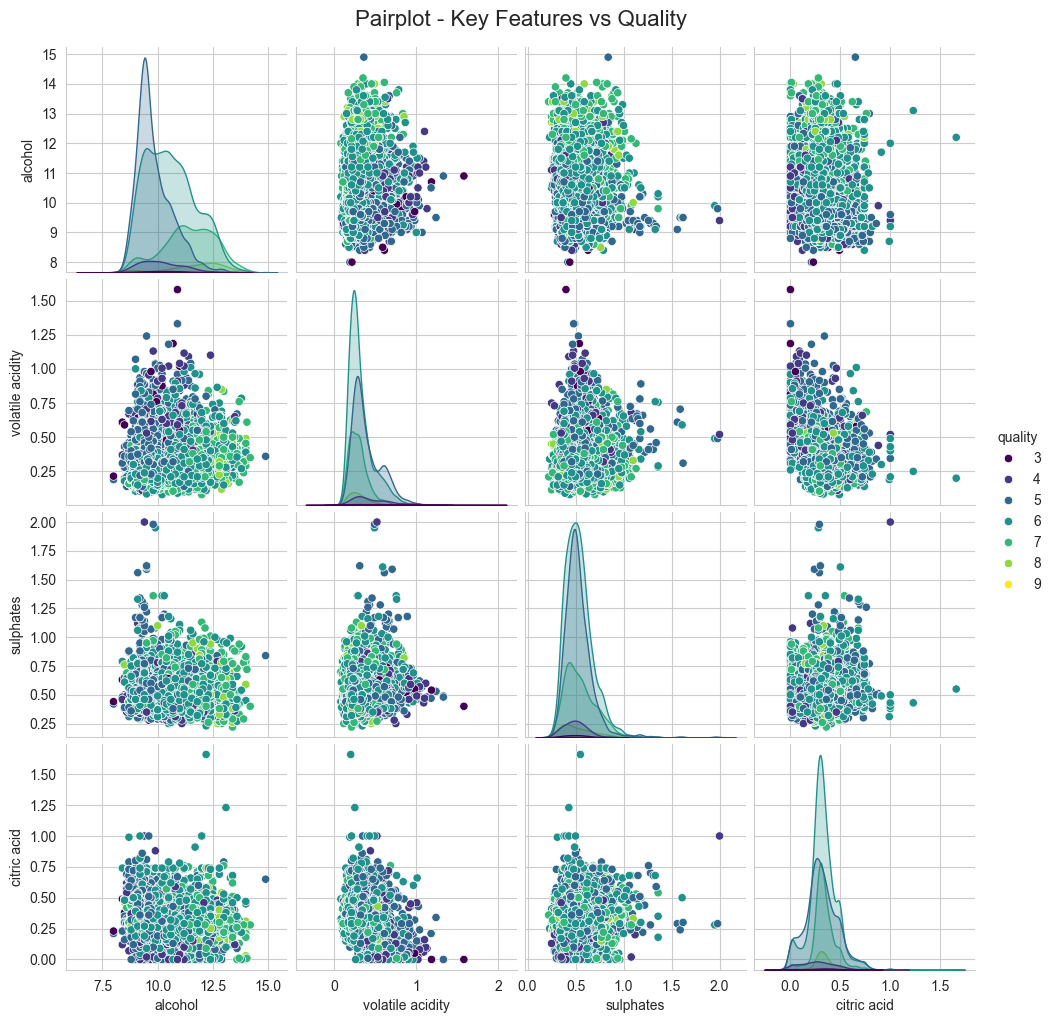

In [13]:
# 4.7 Quality vs Features (Pairplot)
# Select key features for pairplot
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
sns.pairplot(df[key_features], hue='quality', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot - Key Features vs Quality', y=1.02, fontsize=16)
plt.show()

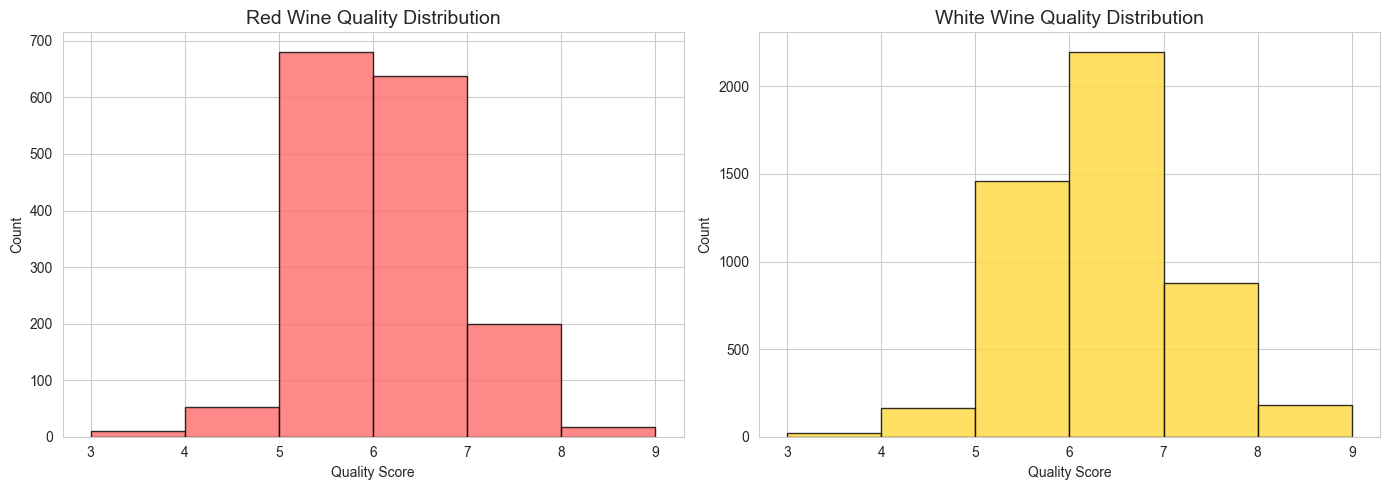

In [14]:
# 4.8 Quality distribution by wine type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, wine in enumerate(['red', 'white']):
    wine_data = df[df['wine_type'] == wine]['quality']
    axes[i].hist(wine_data, bins=range(3, 10), color='#FF6B6B' if wine == 'red' else '#FFD93D',
                 edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{wine.capitalize()} Wine Quality Distribution', fontsize=14)
    axes[i].set_xlabel('Quality Score')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing dilakukan untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Tahapan preprocessing yang dilakukan:
1. Menghapus Data Duplikat
2. Deteksi dan Penanganan Outlier (IQR Clipping)
3. Feature Engineering (Binary target, fitur baru)
4. Encoding Data Kategorikal (LabelEncoder)
5. Train-Test Split
6. Normalisasi/Standarisasi Fitur (StandardScaler)
7. Menyimpan data yang sudah dipreprocess

In [15]:
# 5.1 Menghapus Duplikat
print(f'Shape sebelum hapus duplikat: {df.shape}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape setelah hapus duplikat: {df.shape}')
print(f'Duplikat yang dihapus: {6497 - len(df)}')

Shape sebelum hapus duplikat: (6497, 13)
Shape setelah hapus duplikat: (5320, 13)
Duplikat yang dihapus: 1177


In [16]:
# 5.2 Handling Outliers menggunakan IQR Clipping
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('quality')  # exclude target

outlier_info = {}
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = outliers
    
    # Clip outliers
    df[col] = df[col].clip(lower=lower, upper=upper)

print('Outliers clipped per column:')
for col, count in outlier_info.items():
    if count > 0:
        print(f'  {col}: {count} outliers')

Outliers clipped per column:
  fixed acidity: 304 outliers
  volatile acidity: 279 outliers
  citric acid: 143 outliers
  residual sugar: 141 outliers
  chlorides: 237 outliers
  free sulfur dioxide: 44 outliers
  total sulfur dioxide: 10 outliers
  density: 3 outliers
  pH: 49 outliers
  sulphates: 163 outliers
  alcohol: 1 outliers


In [17]:
# 5.3 Feature Engineering
# Binary target: quality >= 7 = good (1), else bad (0)
df['quality_label'] = (df['quality'] >= 7).astype(int)
print(f'Binary target distribution:')
print(df['quality_label'].value_counts())
print(f'\nPercentage good wine: {df["quality_label"].mean()*100:.2f}%')

# New features
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']
df['free_sulfur_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
df['alcohol_density_ratio'] = df['alcohol'] / (df['density'] + 1e-6)

print(f'\nNew features created: total_acidity, free_sulfur_ratio, alcohol_density_ratio')
print(f'Total columns: {len(df.columns)}')

Binary target distribution:
quality_label
0    4311
1    1009
Name: count, dtype: int64

Percentage good wine: 18.97%

New features created: total_acidity, free_sulfur_ratio, alcohol_density_ratio
Total columns: 17


In [18]:
# 5.4 Encoding Data Kategorikal
le = LabelEncoder()
df['wine_type_encoded'] = le.fit_transform(df['wine_type'])
print(f'Wine type encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Drop kolom yang tidak diperlukan
df = df.drop(columns=['wine_type', 'quality'])
print(f'\nFinal columns: {list(df.columns)}')
print(f'Shape: {df.shape}')

Wine type encoding: {'red': np.int64(0), 'white': np.int64(1)}

Final columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality_label', 'total_acidity', 'free_sulfur_ratio', 'alcohol_density_ratio', 'wine_type_encoded']
Shape: (5320, 16)


In [19]:
# 5.5 Train-Test Split
X = df.drop(columns=['quality_label'])
y = df['quality_label']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total samples: {len(df)}')
print(f'Train samples: {len(X_train)} (80%)')
print(f'Test samples : {len(X_test)} (20%)')
print(f'\nTrain target distribution:\n{y_train.value_counts()}')
print(f'\nTest target distribution:\n{y_test.value_counts()}')

Total samples: 5320
Train samples: 4256 (80%)
Test samples : 1064 (20%)

Train target distribution:
quality_label
0    3449
1     807
Name: count, dtype: int64

Test target distribution:
quality_label
0    862
1    202
Name: count, dtype: int64


In [20]:
# 5.6 Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

print(f'Scaler fitted on {len(feature_names)} features')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape : {X_test_scaled.shape}')
print(f'\nX_train_scaled statistics:')
X_train_scaled.describe().round(3)

Scaler fitted on 15 features
X_train_scaled shape: (4256, 15)
X_test_scaled shape : (1064, 15)

X_train_scaled statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,total_acidity,free_sulfur_ratio,alcohol_density_ratio,wine_type_encoded
count,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000,4256.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.470,-1.744,-2.273,-1.011,-2.032,-1.698,-1.907,-2.569,-2.843,-2.354,-2.148,-2.523,-2.138,-2.102,-1.711
25%,-0.681,-0.730,-0.554,-0.753,-0.715,-0.812,-0.703,-0.791,-0.663,-0.747,-0.883,-0.698,-0.685,-0.874,-1.711
50%,-0.130,-0.257,-0.052,-0.518,-0.306,-0.103,0.041,0.026,-0.021,-0.135,-0.123,-0.176,-0.134,-0.138,0.585
75%,0.512,0.486,0.593,0.584,0.602,0.664,0.679,0.775,0.684,0.554,0.720,0.530,0.523,0.703,0.585
max,2.302,2.310,2.312,2.589,2.465,2.880,2.806,3.142,2.800,2.505,3.083,2.515,4.393,3.104,0.585


In [21]:
# 5.7 Simpan data yang sudah dipreprocess
output_dir = 'winequality_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabung X dan y
train_df = X_train_scaled.copy()
train_df['quality_label'] = y_train.values

test_df = X_test_scaled.copy()
test_df['quality_label'] = y_test.values

train_df.to_csv(f'{output_dir}/train.csv', index=False)
test_df.to_csv(f'{output_dir}/test.csv', index=False)

print(f'Train data saved: {output_dir}/train.csv ({train_df.shape})')
print(f'Test data saved : {output_dir}/test.csv ({test_df.shape})')
print('\nPreprocessing completed!')

Train data saved: winequality_preprocessing/train.csv ((4256, 16))
Test data saved : winequality_preprocessing/test.csv ((1064, 16))

Preprocessing completed!
